### 🤖 LLM and AI Agent Development Courses  
**✨ All courses available for just ₹399 INR / $9.99 USD ✨**

| Course | Description | Enroll |
|--------|-------------|---------|
| **🎯 Master OpenAI Agent Builder** | Build and deploy AI agents visually using OpenAI Agent Builder, ChatKit, RAG, Chatbot, AI Assistant with MCP, AWS, RDS MySQL | [Enroll Now](https://kgptalkie.com/agent-builder) |
| **🔥 MCP Mastery** | Build MCP servers & clients with Python, Streamlit, ChromaDB, LangChain, LangGraph agents, and Ollama integrations | [Enroll Now](https://kgptalkie.com/mcp) |
| **📊 Private Agentic RAG with LangChain** | Step-by-Step Guide to RAG with LangChain v1, LangGraph, and Ollama (Qwen3, Gemma3, DeepSeek-R1, LLAMA, FAISS) | [Enroll Now](https://kgptalkie.com/agentic-rag) |
| **🔧 Master LangGraph and LangChain** | Agentic RAG and Chatbot, AI Agent with LangChain v1, Qwen3, Gemma3, DeepSeek-R1, LLAMA 3.2, FAISS Vector Database | [Enroll Now](https://kgptalkie.com/langgraph) |
| **⚡ Master Langchain and Ollama** | Master Langchain v1, Local LLM Projects with Ollama, Qwen3, Gemma3, DeepSeek-R1, LLAMA 3.2, Complete Integration Guide | [Enroll Now](https://kgptalkie.com/langchain) |
| **🔬 Fine Tuning LLM** | Learn transformer architecture fundamentals and fine-tune LLMs with custom datasets | [Enroll Now](https://kgptalkie.com/fine-tuning-llm) |

---

### 🌐 Join the Community & Stay Connected

- 🔗 **Join the Discord Community:** https://discord.gg/RFjwbkNa  
- 📺 **Subscribe on YouTube (63K+ learners):** http://www.youtube.com/@KGPTalkie

---


## Tool Calling or Function Calling
- LLM Automatically calls the function based on the query
- Function parameters are automatically passed to the function
- It is one of the essential requirements of the Agent
- Not all LLM supports tool calling.

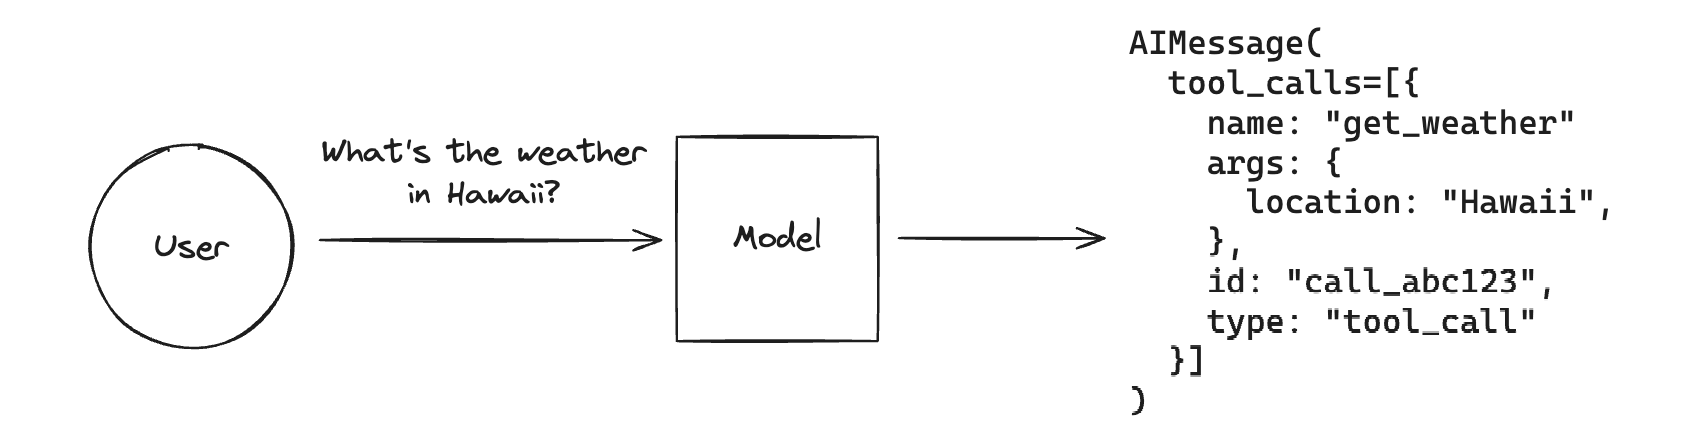

- Chat models that support tool calling features implement a .bind_tools() method for passing tool schemas to the model.

In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
from langfuse.langchain import CallbackHandler

langfuce_trace = CallbackHandler()

In [3]:
from langchain_ollama import ChatOllama 
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough 
from langchain_core.prompts import ChatPromptTemplate

# llm = ChatOllama(model='qwen3', base_url='http://localhost:11434')
# llm = ChatOllama(model='gemma4', base_url='http://localhost:11434', reasoning=False) # reasoning=False -> turn-off thinking mode
# llm = ChatOllama(model='deepseek-r1', base_url='http://localhost:11434', reasoning=False) # reasoning=False -> turn-off thinking mode
llm = ChatOllama(model='llama3.2', base_url='http://localhost:11434', reasoning=False) # reasoning=False -> turn-off thinking mode
llm.invoke('hi')

AIMessage(content='How can I assist you today?', additional_kwargs={}, response_metadata={'model': 'llama3.2', 'created_at': '2026-05-29T03:56:15.219484035Z', 'done': True, 'done_reason': 'stop', 'total_duration': 31091346431, 'load_duration': 30080101855, 'prompt_eval_count': 26, 'prompt_eval_duration': 478609311, 'eval_count': 8, 'eval_duration': 518028723, 'logprobs': None, 'model_name': 'llama3.2', 'model_provider': 'ollama'}, id='lc_run--019e71df-aa7a-7a21-ae29-8c4c1497bee8-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 26, 'output_tokens': 8, 'total_tokens': 34})

### Custom Tools

In [4]:
### Tool Creation

from langchain_core.tools import tool

@tool
def add(a, b):
    """
    Add two integer numbers together
    
    Args:
    a: First Integer
    b: Second Integer
    """
    return a + b

@tool
def multiply(a, b):
    """
    Multiply two integer numbers together
    
    Args:
    a: First Integer
    b: Second Integer
    """
    return a * b




In [5]:
# type(add)
# add.__dict__

In [6]:
add.name, add.description, add.args, add.args_schema.model_json_schema()

('add',
 'Add two integer numbers together\n\nArgs:\na: First Integer\nb: Second Integer',
 {'a': {'title': 'A'}, 'b': {'title': 'B'}},
 {'description': 'Add two integer numbers together\n\nArgs:\na: First Integer\nb: Second Integer',
  'properties': {'a': {'title': 'A'}, 'b': {'title': 'B'}},
  'required': ['a', 'b'],
  'title': 'add',
  'type': 'object'})

In [7]:
add.invoke({'a': 1, 'b': 2})

3

In [8]:
multiply.invoke({'a': 67, 'b': 2})

134

In [5]:
tools = [add, multiply]
llm_with_tools = llm.bind_tools(tools)

In [6]:
question  = "what is 1 plus 2?"
llm_with_tools.invoke(question, config={"callbacks": [langfuce_trace]}).tool_calls

[{'name': 'add',
  'args': {'a': '1', 'b': '2'},
  'id': '42d4914e-0347-4461-9b59-f306a637d61f',
  'type': 'tool_call'}]

In [7]:
question  = "what is 1 multiplied by 2?"
llm_with_tools.invoke(question).tool_calls

[{'name': 'multiply',
  'args': {'a': '1', 'b': '2'},
  'id': '8ec692fa-9397-436f-b4f3-1ded3c52fd36',
  'type': 'tool_call'}]

In [8]:
question  = "what is 1 multiplied by 2, also what is 11 plus 22?"
llm_with_tools.invoke(question).tool_calls

[{'name': 'multiply',
  'args': {'a': 1, 'b': 2},
  'id': '379ca951-dbbf-41fe-a943-47887ea7c26d',
  'type': 'tool_call'},
 {'name': 'add',
  'args': {'a': 11, 'b': 22},
  'id': 'b56a6c5d-9eed-4b59-984e-5f6fc6f7f944',
  'type': 'tool_call'}]

## Calling In-Built Tool 
### DuckDuckGo Search
- There are so many other paid options are also available like Tavily, Google, Bing, etc.

In [13]:
# https://python.langchain.com/docs/integrations/tools/

# !pip install -qU ddgs wikipedia xmltodict tavily-python

In [13]:
from ddgs import DDGS

@tool
def web_search(query: str) -> str:
    """Search the web using DuckDuckGo."""

    with DDGS(timeout=60) as ddgs:
        results = list(ddgs.text(query, max_results=2))

    return "\n".join(
        f"{r['title']}\n{r['href']}\n{r['body']}"
        for r in results
    )


In [14]:
from langchain_community.tools import DuckDuckGoSearchRun

# search = DuckDuckGoSearchRun()
# search.invoke("What is today's stock market news?")

web_search.invoke("What is today's stock market news?")


TimeoutException: error sending request for url (https://search.yahoo.com/search;_ylt=ttzGaQmfSWvIhx7z7jijMJhQ;_ylu=Ef0M1NttrcsqrDsxvGrUs7zrGSmboNzxRdTi6-OA3gBYzWw?p=What+is+today%27s+stock+market+news%3F) > client error (Connect) > dns error > DNS resolution timed out after 10s

### Tavily Search

In [15]:
from langchain_community.tools import TavilySearchResults

search = TavilySearchResults(
    max_results=5,
    search_depth="advanced",
    include_answer=True,
    include_raw_content=True,
)

C:\Users\Tho Le\AppData\Local\Temp\ipykernel_19180\2365025788.py:3: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  search = TavilySearchResults(


In [16]:
question = "what is today's stock market news?"
search.invoke(question)

[{'title': 'MarketWatch: Stock Market News - Financial News - MarketWatch',
  'url': 'https://www.marketwatch.com',
  'content': '7:45 PM\n\nOpinion\n\nEarnings season slows but these 7 stocks pack explosive ‘sawtooth’ volatility next week\n\n6:44 PM\n\nCostco gas demand hits records, as shoppers try to stay ahead of future price spikes\n\n5:58 PM\n\nThis overvalued stock market just flashed a rare buy signal\n\n5:58 PM\n\nOpinion\n\nThe Iran war costs more than you think — it boosts inflation and threatens stocks\n\n5:46 PM\n\n67 million kids haven’t signed up for ‘Trump accounts.’ Here’s what they could be missing out on.\n\n### An Iran deal could actually trigger a painful stock-market selloff, despite Wall Street’s optimism\n\n### Dell’s stock soars nearly 40% toward another record high as AI boom drives big earnings beat\n\n### Want an alternative to chip stocks? This sector with an AI angle is breaking out. [...] ### ‘There is zero transparency’: My friend’s sister controls their

### Wikipedia Search

In [20]:
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

wikipedia = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper())
question = "what is the capital of France?"
# question = "What is LLM?"
result = wikipedia.invoke(question)
result

# print(wikipedia.invoke(question))


JSONDecodeError: Expecting value: line 1 column 1 (char 0)

### PubMed

- PubMed® comprises more than 35 million citations for biomedical literature from MEDLINE, life science journals, and online books. Citations may include links to full text content from PubMed Central and publisher web sites.



In [22]:
from langchain_community.tools.pubmed.tool import PubmedQueryRun

search = PubmedQueryRun()

print(search.invoke("What is the latest research on COVID-19?"))

No good PubMed Result was found


### Tool Calling with LLM

In [23]:
@tool
def wikipedia_search(query):
    """
    Search wikipedia for general information.
    
    Args:
    query: The search query
    """
    
    wikipedia = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper())
    response = wikipedia.invoke(query)
    return response

@tool
def pubmed_search(query):
    """
    Search pubmed for medical and life sciences queries.
    
    Args:
    query: The search query
    """
    
    search = PubmedQueryRun()
    response = search.invoke(query)
    return response

@tool
def tavily_search(query):
    """
    Search the web for realtime and latest information.
    for examples, news, stock market, weather updates etc.
    
    Args:
    query: The search query
    """
    
    search = TavilySearchResults(
        max_results=5,
        search_depth="advanced",
        include_answer=True,
        include_raw_content=True,
    )
    response = search.invoke(query)
    return response


@tool
def multiply(a:int, b:int)->int:
    """
    Multiply two integer numbers together
    
    Args:
    a: First Integer
    b: Second Integer
    """
    return int(a) * int(b)


In [24]:
# tools = [wikipedia_search, pubmed_search, tavily_search, multiply]
tools = [wikipedia_search, pubmed_search, multiply]

list_of_tools = { tool.name: tool for tool in tools }

In [25]:
list_of_tools

{'wikipedia_search': StructuredTool(name='wikipedia_search', description='Search wikipedia for general information.\n\nArgs:\nquery: The search query', args_schema=<class 'langchain_core.utils.pydantic.wikipedia_search'>, func=<function wikipedia_search at 0x000001AFE0CA1440>),
 'pubmed_search': StructuredTool(name='pubmed_search', description='Search pubmed for medical and life sciences queries.\n\nArgs:\nquery: The search query', args_schema=<class 'langchain_core.utils.pydantic.pubmed_search'>, func=<function pubmed_search at 0x000001AFE0CA14E0>),
 'multiply': StructuredTool(name='multiply', description='Multiply two integer numbers together\n\nArgs:\na: First Integer\nb: Second Integer', args_schema=<class 'langchain_core.utils.pydantic.multiply'>, func=<function multiply at 0x000001AFE0CA1BC0>)}

In [26]:
llm_with_tools = llm.bind_tools(tools)

In [27]:
# query = "What is the latest news"
# query = "What is today's stock market news?"
# query = "What is LLM?"
# query = "How to treat lung cancer?"
query  = "what is 2 * 3?"
response = llm_with_tools.invoke(query, config={"callbacks": [langfuce_trace]})
print(response.tool_calls)

[{'name': 'multiply', 'args': {'a': '2', 'b': '3'}, 'id': 'b96c5428-de8f-4b47-9faa-257d716c0fc3', 'type': 'tool_call'}]


### Generate Final Result with Tool Calling

In [29]:
from langchain_core.messages import HumanMessage, AIMessage

In [30]:
# query = "What is the latest news"
# query = "What is today's stock market news?"
# query = "What is LLM?"
query = "How to treat lung cancer?"
# query  = "what is 2 * 3?"

messages = [HumanMessage(query)]

tool_calls = llm_with_tools.invoke(messages)

messages.append(tool_calls)

tool_calls = tool_calls.tool_calls


In [31]:
from langchain_core.messages import HumanMessage

# query = "What is the latest news"
# query = "What is today's stock market news?"
# query = "What is LLM?"
query = "What is medicine for lung cancer?"
# query  = "what is 2 * 3?"

messages = [HumanMessage(query)]

ai_msg = llm_with_tools.invoke(messages)

messages.append(ai_msg)

In [32]:
for tool_call in ai_msg.tool_calls:
    print(tool_call)

    name = tool_call['name'].lower()

    selected_tool = list_of_tools[name]

    tool_msg = selected_tool.invoke(tool_call)

    messages.append(tool_msg)

{'name': 'wikipedia_search', 'args': {'query': {'query': 'medicine for lung cancer'}}, 'id': '2b233b97-825f-4cd8-a56f-5c5ef65cdcc4', 'type': 'tool_call'}


In [34]:
messages

[HumanMessage(content='What is medicine for lung cancer?', additional_kwargs={}, response_metadata={}),
 AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'llama3.2', 'created_at': '2026-05-29T04:22:53.083104121Z', 'done': True, 'done_reason': 'stop', 'total_duration': 2952478531, 'load_duration': 770381331, 'prompt_eval_count': 250, 'prompt_eval_duration': 268135890, 'eval_count': 25, 'eval_duration': 1881109717, 'logprobs': None, 'model_name': 'llama3.2', 'model_provider': 'ollama'}, id='lc_run--019e71f8-7a0e-7260-9abf-9897bba30e91-0', tool_calls=[{'name': 'wikipedia_search', 'args': {'query': {'query': 'medicine for lung cancer'}}, 'id': '2b233b97-825f-4cd8-a56f-5c5ef65cdcc4', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 250, 'output_tokens': 25, 'total_tokens': 275}),
 ToolMessage(content="Page: Non-small-cell lung cancer\nSummary: Non-small-cell lung cancer (NSCLC), or non-small-cell lung carcinoma, is a type of epithelial lun

In [36]:
response = llm_with_tools.invoke(messages, config={"callbacks": [langfuce_trace]})
print(response.content)

**Medicines for Lung Cancer**

Lung cancer is a complex disease with various treatment options, depending on the type and stage of the cancer. The following are some common medicines used to treat lung cancer:

1. **Non-Small-Cell Lung Cancer (NSCLC)**:
	* Chemotherapy medications such as:
		+ Carboldehyde-based chemotherapy
		+ Alkylating agents like carboplatin and cisplatin
		+ Antitumor antibiotics like doxorubicin and bleomycin
	* Targeted therapies like:
		+ Erlotinib (Tarceva) for patients with EGFR mutations
		+ Crizotinib (Xalkori) for patients with ALK rearrangements
2. **Small-Cell Lung Cancer (SCLC)**:
	* Chemotherapy medications such as:
		+ Cisplatin and etoposide (EC)
		+ Carboplatin and docetaxel (Taxotere)
	* Radiation therapy to control symptoms and reduce tumor size
3. **Targeted Therapies**:
	* Medications like gefitinib (Iressa), erlotinib (Tarceva), and crizotinib (Xalkori) are used to treat NSCLC with specific genetic mutations.
4. **Immunotherapy**:
	* Medicatio